In [1]:
!gcloud auth application-default login

Your browser has been opened to visit:

    https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=764086051850-6qr4p6gpi6hn506pt8ejuq83di341hur.apps.googleusercontent.com&redirect_uri=http%3A%2F%2Flocalhost%3A8085%2F&scope=openid+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fuserinfo.email+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcloud-platform+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fsqlservice.login&state=G6kNCMK5m1B6h8cSoZzv7be2KDRP4L&access_type=offline&code_challenge=Lo9RRyfcOZHp1Qt2WkazeKBRW1MBIHzpDFsPK-IbJyk&code_challenge_method=S256


Credentials saved to file: [/Users/yt4/.config/gcloud/application_default_credentials.json]

These credentials will be used by any library that requests Application Default Credentials (ADC).

Quota project "open-targets-genetics-dev" was added to ADC which can be used by Google client libraries for billing and quota. Note that some services may still bill the project owning the resource.


Updates are available for some Google Clo

In [2]:
import os

import hail as hl
import numpy as np
import pyspark.sql.functions as f
from pyspark.sql import DataFrame

from gentropy.common.session import Session
from gentropy.dataset.study_index import StudyIndex
from gentropy.dataset.summary_statistics import SummaryStatistics
from gentropy.dataset.study_locus import StudyLocus
from gentropy.susie_finemapper import SusieFineMapperStep
from gentropy.method.drug_enrichment_from_evid import chemblDrugEnrichment

"""Common utilities for the project."""

import os
from pathlib import Path
from gentropy.common.session import Session
import logging


def get_gcs_credentials() -> str:
    """Get the credentials for google cloud storage."""
    app_default_credentials = os.path.join(
        os.getenv("HOME", "."), ".config/gcloud/application_default_credentials.json"
    )

    service_account_credentials = os.path.join(
        os.getenv("HOME", "."), ".config/gcloud/service_account_credentials.json"
    )

    if Path(app_default_credentials).exists():
        return app_default_credentials
    else:
        raise FileNotFoundError("No GCS credentials found.")


def get_gcs_hadoop_connector_jar() -> str:
    """Get the google cloud storage hadoop connector for spark.

    This function will return the url to download the hadoop jar.
    """

    return (
        "https://storage.googleapis.com/hadoop-lib/gcs/gcs-connector-hadoop3-latest.jar"
    )


def gcs_conf(
    credentials_path=None, project="open-targets-genetics-dev"
) -> dict[str, str]:
    """Get the spark configuration with hadoop connector for google cloud storage."""
    credentials_path = credentials_path or get_gcs_credentials()
    return {
        "spark.driver.memory": "12g",
        "spark.kryoserializer.buffer.max": "500m",
        "spark.driver.maxResultSize":"2g",
        "spark.hadoop.fs.gs.impl": "com.google.cloud.hadoop.fs.gcs.GoogleHadoopFileSystem",
        "spark.jars": get_gcs_hadoop_connector_jar(),
        "spark.hadoop.google.cloud.auth.service.account.enable": "true",
        "spark.hadoop.fs.gs.project.id": project,
        "spark.hadoop.google.cloud.auth.service.account.json.keyfile": credentials_path,
        "spark.hadoop.fs.gs.requester.pays.mode": "AUTO",
    }


class GentropySession(Session):
    def __init__(self, *args, **kwargs):
        if "extended_spark_conf" in kwargs:
            kwargs["extended_spark_conf"].update(gcs_conf())
        else:
            kwargs["extended_spark_conf"] = gcs_conf()
        super().__init__(*args, **kwargs)

    @property
    def conf(self):
        logging.warning(
            "To change the config restart the session and use the `extended_spark_conf` parameter."
        )
        return self.spark.sparkContext.getConf().getAll()

session= GentropySession()


path_to_release_folder="gs://open-targets-data-releases/25.06/"
#path_to_release_folder="gs://open-targets-pre-data-releases/24.12-uo_test-3/output/genetics/parquet/"
#path_to_release_folder="gs://ot_orchestration/releases/25.02_freeze1/"

si=StudyIndex.from_parquet(session,path_to_release_folder+"output/study/")
sl=StudyLocus.from_parquet(session,path_to_release_folder+"output/credible_set/")

Loading BokehJS ...

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/06/27 12:35:46 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
disease_index_path=path_to_release_folder+"output/disease/disease.parquet"
disease_index_orig = session.spark.read.parquet(disease_index_path)

platform_chembl_evidence_path=path_to_release_folder+"output/evidence/sourceId=chembl"
chembl_evidence=session.spark.read.parquet(platform_chembl_evidence_path)

In [4]:
import pandas as pd
all_enrich = []

In [5]:
l2g_2506=session.spark.read.parquet(path_to_release_folder+"output/l2g_prediction")

In [6]:
coln="2506_l2g"
evidence=chemblDrugEnrichment.to_disease_target_evidence(table_with_score=l2g_2506,
    score_column="score",
    datasource_id=coln,
    study_locus=sl,
    study_index=si,
    min_score=0.5
)
enrich=chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence,
    disease_index_orig=disease_index_orig,
    chembl_orig=chembl_evidence, 
    indirect_assoc_score_thr=0.5,
    efo_ancestors_to_remove=["MONDO_0045024"]
)
enrich["datasource"] = coln
all_enrich.append(enrich)

In [7]:
path_to_release_folder="gs://open-targets-data-releases/25.03/"
l2g_2503=session.spark.read.parquet(path_to_release_folder+"output/l2g_prediction")

In [8]:
coln="2503_l2g"
evidence=chemblDrugEnrichment.to_disease_target_evidence(table_with_score=l2g_2503,
    score_column="score",
    datasource_id=coln,
    study_locus=sl,
    study_index=si,
    min_score=0.5
)
enrich=chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence,
    disease_index_orig=disease_index_orig,
    chembl_orig=chembl_evidence, 
    indirect_assoc_score_thr=0.5,
    efo_ancestors_to_remove=["MONDO_0045024"]
)
enrich["datasource"] = coln
all_enrich.append(enrich)

In [9]:
l2g_2507=session.spark.read.parquet("gs://ot-team/irene/l2g/xgboost/2706/l2g_predictions")

In [10]:
l2g_2507.show(1)

25/06/27 12:38:46 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+---------------+--------------------+---------------------+---------------------+----------------------------------+-------------------------+--------------------------------------+-------------------+--------------------------------+---------------+----------------------------+--------------------+---------------------------------+------------------+-------------------------------+--------------+--------------------+---------------------------------+------------------+-------------------------------+---------------------+--------------------+---------------------------------+------------------+-------------------------------+----------+-----------------------+-------+--------------------+-----------+
|         geneId|        studyLocusId|credibleSetConfidence|distanceFootprintMean|distanceFootprintMeanNeighbourhood|distanceSentinelFootprint|distanceSentinelFootprintNeighbourhood|distanceSentinelTss|distanceSentinelTssNeighbourhood|distanceTssMean|distanceTssMeanNeighbourhood|eQtlColo

In [11]:
coln="2507_l2g"
evidence=chemblDrugEnrichment.to_disease_target_evidence(table_with_score=l2g_2507,
    score_column="score",
    datasource_id=coln,
    study_locus=sl,
    study_index=si,
    min_score=0.5
)
enrich=chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence,
    disease_index_orig=disease_index_orig,
    chembl_orig=chembl_evidence, 
    indirect_assoc_score_thr=0.5,
    efo_ancestors_to_remove=["MONDO_0045024"]
)
enrich["datasource"] = coln
all_enrich.append(enrich)

In [8]:
colnames=["20250624_full_EGL_max2_no_inter_training_set.tsv","20250624_full_EGL_max2_string07_training_set_v2.tsv",
"20250624_full_EGL_max2_string07_training_set.tsv","2503_training_set_v2.tsv",
"2503_training_set.tsv","2506_train_set.tsv","250624_training_set.tsv",
"20250624_full_EGL_max2_string08_dist_training_set.tsv","20250624_full_EGL_max2_string08_dist_training_set_v2.tsv",
"20250625_restrict_EGL_v1_max2_string08_dist_training_set.tsv","20250625_restrict_EGL_v1_max2_string08_dist_training_set_v2.tsv"]

In [9]:
coln="20250624_full_EGL_max2_no_inter_training_set.tsv"
x=session.spark.read.csv("../gentropy_paper/data/l2g_predictions/"+coln,header=True,sep=",")

In [10]:
x.show(1)

+--------------------+---------------+------------------+
|        studyLocusId|         geneId|             score|
+--------------------+---------------+------------------+
|55264f2df1bf4e432...|ENSG00000005189|0.0793329700827599|
+--------------------+---------------+------------------+
only showing top 1 row



In [11]:
for coln in colnames:
    print(coln)
    df=session.spark.read.csv("../gentropy_paper/data/l2g_predictions/"+coln,header=True,sep=",")
    evidence=chemblDrugEnrichment.to_disease_target_evidence(table_with_score=df,
        score_column="score",
        datasource_id=coln,
        study_locus=sl,
        study_index=si,
        min_score=0.5
    ).cache()
    enrich=chemblDrugEnrichment.drug_enrichemnt_from_evidence(
        evid=evidence,
        disease_index_orig=disease_index_orig,
        chembl_orig=chembl_evidence,
        indirect_assoc_score_thr=0.5,
        efo_ancestors_to_remove=["MONDO_0045024"]
    )
    enrich["datasource"] = coln
    all_enrich.append(enrich)

20250624_full_EGL_max2_no_inter_training_set.tsv


20250624_full_EGL_max2_string07_training_set_v2.tsv


20250624_full_EGL_max2_string07_training_set.tsv


2503_training_set_v2.tsv


2503_training_set.tsv


2506_train_set.tsv


250624_training_set.tsv


20250624_full_EGL_max2_string08_dist_training_set.tsv


20250624_full_EGL_max2_string08_dist_training_set_v2.tsv


20250625_restrict_EGL_v1_max2_string08_dist_training_set.tsv


20250625_restrict_EGL_v1_max2_string08_dist_training_set_v2.tsv


In [12]:
si_mvp=si.df.filter(f.col("pubmedId")==39024449).select("studyId")
sl_mvp=sl.df.join(si_mvp,on="studyId",how="inner").select("studyLocusId").distinct().cache()
sl_mvp.count()

171951

In [13]:
for coln in colnames:
    print(coln)
    df=session.spark.read.csv("../gentropy_paper/data/l2g_predictions/"+coln,header=True,sep=",")
    df=df.join(sl_mvp,on="studyLocusId",how="left_anti")
    evidence=chemblDrugEnrichment.to_disease_target_evidence(table_with_score=df,
        score_column="score",
        datasource_id=coln,
        study_locus=sl,
        study_index=si,
        min_score=0.5
    ).cache()
    enrich=chemblDrugEnrichment.drug_enrichemnt_from_evidence(
        evid=evidence,
        disease_index_orig=disease_index_orig,
        chembl_orig=chembl_evidence,
        indirect_assoc_score_thr=0.5,
        efo_ancestors_to_remove=["MONDO_0045024"]
    )
    enrich["datasource"] = coln+"_no_mvp"
    all_enrich.append(enrich)

20250624_full_EGL_max2_no_inter_training_set.tsv


20250624_full_EGL_max2_string07_training_set_v2.tsv


20250624_full_EGL_max2_string07_training_set.tsv


2503_training_set_v2.tsv


2503_training_set.tsv


2506_train_set.tsv


250624_training_set.tsv


20250624_full_EGL_max2_string08_dist_training_set.tsv


20250624_full_EGL_max2_string08_dist_training_set_v2.tsv


20250625_restrict_EGL_v1_max2_string08_dist_training_set.tsv


20250625_restrict_EGL_v1_max2_string08_dist_training_set_v2.tsv


In [13]:
coln="2506_l2g_no_mvp"
l2g_2506_no_mvp=l2g_2506.join(sl_mvp,on="studyLocusId",how="left_anti")
evidence=chemblDrugEnrichment.to_disease_target_evidence(table_with_score=l2g_2506_no_mvp,
    score_column="score",
    datasource_id=coln,
    study_locus=sl,
    study_index=si,
    min_score=0.5
)
enrich=chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence,
    disease_index_orig=disease_index_orig,
    chembl_orig=chembl_evidence, 
    indirect_assoc_score_thr=0.5,
    efo_ancestors_to_remove=["MONDO_0045024"]
)
enrich["datasource"] = coln
all_enrich.append(enrich)

In [14]:
coln="2507_l2g_no_mvp"
l2g_2507_no_mvp=l2g_2507.join(sl_mvp,on="studyLocusId",how="left_anti")
evidence=chemblDrugEnrichment.to_disease_target_evidence(table_with_score=l2g_2507_no_mvp,
    score_column="score",
    datasource_id=coln,
    study_locus=sl,
    study_index=si,
    min_score=0.5
)
enrich=chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence,
    disease_index_orig=disease_index_orig,
    chembl_orig=chembl_evidence, 
    indirect_assoc_score_thr=0.5,
    efo_ancestors_to_remove=["MONDO_0045024"]
)
enrich["datasource"] = coln
all_enrich.append(enrich)

In [22]:
colnames=["20250625_gentropy_paper_v1.tsv","20250625_gentropy_paper_v1_v2.tsv"]

In [23]:
for coln in colnames:
    print(coln)
    df=session.spark.read.csv("../gentropy_paper/data/l2g_predictions/"+coln,header=True,sep=",")
    evidence=chemblDrugEnrichment.to_disease_target_evidence(table_with_score=df,
        score_column="score",
        datasource_id=coln,
        study_locus=sl,
        study_index=si,
        min_score=0.5
    ).cache()
    enrich=chemblDrugEnrichment.drug_enrichemnt_from_evidence(
        evid=evidence,
        disease_index_orig=disease_index_orig,
        chembl_orig=chembl_evidence,
        indirect_assoc_score_thr=0.5,
        efo_ancestors_to_remove=["MONDO_0045024"]
    )
    enrich["datasource"] = coln
    all_enrich.append(enrich)

20250625_gentropy_paper_v1.tsv


20250625_gentropy_paper_v1_v2.tsv


In [24]:
for coln in colnames:
    print(coln)
    df=session.spark.read.csv("../gentropy_paper/data/l2g_predictions/"+coln,header=True,sep=",")
    df=df.join(sl_mvp,on="studyLocusId",how="left_anti")
    evidence=chemblDrugEnrichment.to_disease_target_evidence(table_with_score=df,
        score_column="score",
        datasource_id=coln,
        study_locus=sl,
        study_index=si,
        min_score=0.5
    ).cache()
    enrich=chemblDrugEnrichment.drug_enrichemnt_from_evidence(
        evid=evidence,
        disease_index_orig=disease_index_orig,
        chembl_orig=chembl_evidence,
        indirect_assoc_score_thr=0.5,
        efo_ancestors_to_remove=["MONDO_0045024"]
    )
    enrich["datasource"] = coln+"_no_mvp"
    all_enrich.append(enrich)

20250625_gentropy_paper_v1.tsv


20250625_gentropy_paper_v1_v2.tsv


In [15]:
combined_enrich = pd.concat(all_enrich, ignore_index=True)

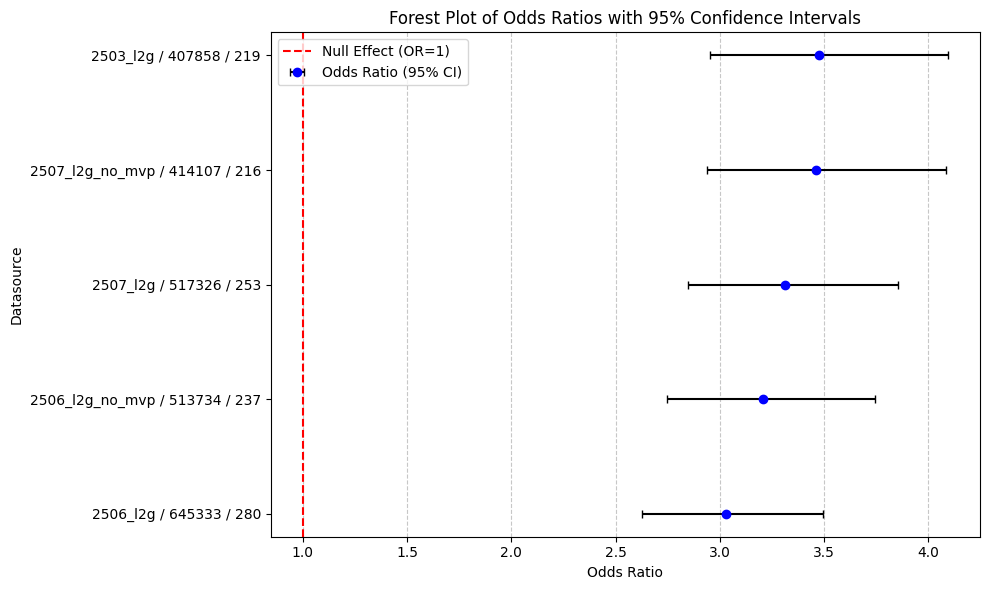

In [16]:
import matplotlib.pyplot as plt

# Assuming `combined_enrich` is your pandas DataFrame
# Sort the DataFrame by odds_ratio for better visualization
combined_enrich_4=combined_enrich[combined_enrich["clinicalPhase"]=="4+"]
combined_enrich_4 = combined_enrich_4.sort_values(by="odds_ratio", ascending=True)

# Extract data for the plot
datasources = combined_enrich_4.apply(
    lambda row: f"{row['datasource']} / {row['total_indirect_assoc']} / {row['yes_evid-high_clinphase']}", axis=1
)
odds_ratios = combined_enrich_4["odds_ratio"]
ci_low = combined_enrich_4["ci_low"]
ci_high = combined_enrich_4["ci_high"]

# Create the forest plot
plt.figure(figsize=(10, 6))
plt.errorbar(odds_ratios, datasources, xerr=[odds_ratios - ci_low, ci_high - odds_ratios], fmt='o', color='blue', ecolor='black', capsize=3, label="Odds Ratio (95% CI)")

# Add labels and title
plt.axvline(x=1, color='red', linestyle='--', label="Null Effect (OR=1)")
plt.xlabel("Odds Ratio")
plt.ylabel("Datasource")
plt.title("Forest Plot of Odds Ratios with 95% Confidence Intervals")
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

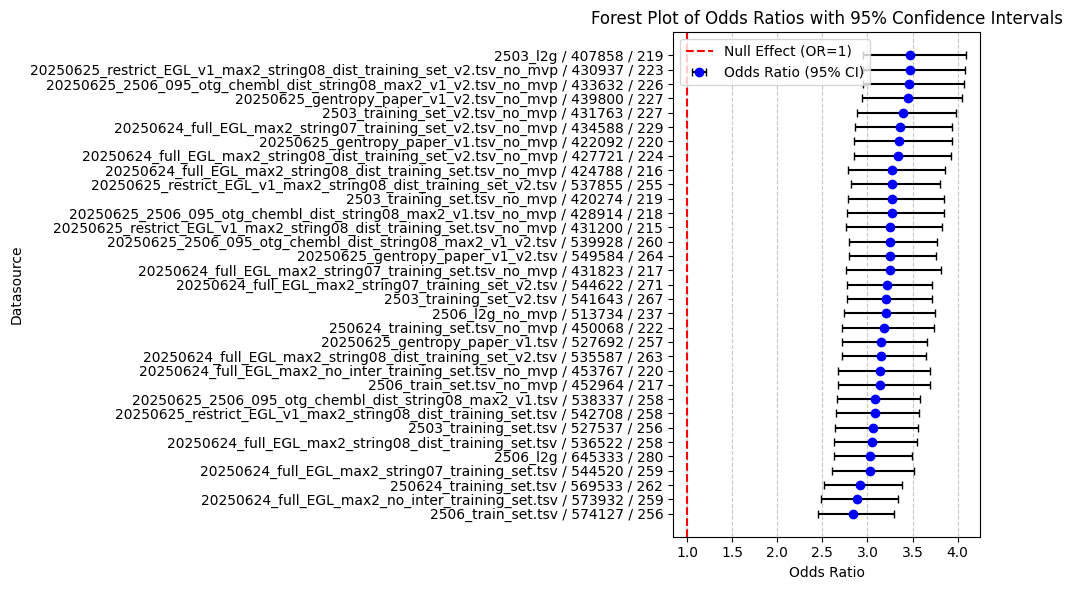

In [26]:
import matplotlib.pyplot as plt

# Assuming `combined_enrich` is your pandas DataFrame
# Sort the DataFrame by odds_ratio for better visualization
combined_enrich_4=combined_enrich[combined_enrich["clinicalPhase"]=="4+"]
combined_enrich_4 = combined_enrich_4.sort_values(by="odds_ratio", ascending=True)

# Extract data for the plot
datasources = combined_enrich_4.apply(
    lambda row: f"{row['datasource']} / {row['total_indirect_assoc']} / {row['yes_evid-high_clinphase']}", axis=1
)
odds_ratios = combined_enrich_4["odds_ratio"]
ci_low = combined_enrich_4["ci_low"]
ci_high = combined_enrich_4["ci_high"]

# Create the forest plot
plt.figure(figsize=(10, 6))
plt.errorbar(odds_ratios, datasources, xerr=[odds_ratios - ci_low, ci_high - odds_ratios], fmt='o', color='blue', ecolor='black', capsize=3, label="Odds Ratio (95% CI)")

# Add labels and title
plt.axvline(x=1, color='red', linestyle='--', label="Null Effect (OR=1)")
plt.xlabel("Odds Ratio")
plt.ylabel("Datasource")
plt.title("Forest Plot of Odds Ratios with 95% Confidence Intervals")
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()